In [1]:
import os
import yaml
import json
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


## Code

In [2]:
def process_phenotypes_prs_long(
    gene_trait_df: pl.DataFrame,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    config: dict,
) -> pl.DataFrame:
    """
    Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
    """
    print("Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.")
    
    # --- Step 1: Unique phenotypes ---
    unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
    if not unique_phenotypes:
        raise ValueError("No phenotypes found in gene_trait_df")

    # --- Step 2: Read data lazily ---
    phenos_lazy = (
        pl.scan_parquet(pheno_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + unique_phenotypes)
        .drop_nulls()
    )

    prs_cols = [f"{pheno}_prs" for pheno in unique_phenotypes]
    prs_lazy = (
        pl.scan_parquet(prs_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + prs_cols)
        .drop_nulls()
    )

    cov_list = config.get("covariates", [])
    cov_lazy = (
        pl.scan_parquet(cov_path)
        .rename({'sample': 'individual'})
        .select(['individual'] + cov_list)
        .with_columns(pl.col('individual').cast(pl.Int64))
    )

    # --- Step 3: Merge all into one lazy DataFrame ---
    all_lazy = phenos_lazy.join(prs_lazy, on='individual', how='inner').join(
        cov_lazy, on='individual', how='inner'
    )
    
    # Collect once for regression computations (still needed for statsmodels)
    all_pd = all_lazy.collect().to_pandas()

    # --- Step 4: Compute residuals ---
    all_residuals_dfs = []

    for phenotype in unique_phenotypes:
        try:
            pheno_cols = [phenotype, f"{phenotype}_prs"] + cov_list
            temp_df = all_pd[['individual'] + pheno_cols].dropna()
            if len(temp_df) == 0:
                print(f"No data for phenotype: {phenotype}")
                continue

            y = temp_df[phenotype]
            X = temp_df.drop(columns=[phenotype, 'individual'])
            X = sm.add_constant(X)

            model = sm.OLS(y, X).fit()
            residuals = pd.Series(model.resid, index=temp_df.index, name=f"{phenotype}_residual")

            pheno_residuals = pd.concat([temp_df[['individual']], residuals], axis=1)
            all_residuals_dfs.append(pheno_residuals)

        except Exception as e:
            print(f"Error processing phenotype {phenotype}: {e}")
            continue

    if not all_residuals_dfs:
        raise ValueError("No residuals could be computed")

    # --- Step 5: Convert to long-format lazy DataFrame ---
    long_lazy_dfs = []
    for residual_df in all_residuals_dfs:
        p_wide_lazy = pl.LazyFrame(residual_df).with_columns(
            pl.col('individual').cast(pl.String)
        )
        pheno_cols = [c for c in residual_df.columns if c.endswith('_residual')]
        pdf_lazy = (
            p_wide_lazy.unpivot(
                index=['individual'],
                on=pheno_cols,
                variable_name='phenotype',
                value_name='pheno_value',
            )
            .with_columns(
                pl.col('phenotype').str.replace('_residual', '').alias('phenotype')
            )
        )
        long_lazy_dfs.append(pdf_lazy)

    combined_pdf_lazy = pl.concat(long_lazy_dfs) if len(long_lazy_dfs) > 1 else long_lazy_dfs[0]

    return combined_pdf_lazy.collect()

def process_gene_genotypes(
    gene_id: str, 
    regions_dict: dict, 
    sample_list: list
) -> pl.LazyFrame:
    """
    Extract genotypes for a specific gene and return as lazy DataFrame
    """
    try:
        reg_dict = regions_dict[gene_id]
        geno = reg_dict['genotypes']
        
        # Find heterozygous genotypes (genotype == 1)
        rows, cols = np.where(geno == 1)
        het = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 1
        })
        
        # Find homozygous genotypes (genotype == 2)
        rows, cols = np.where(geno == 2)
        hom = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 2
        })
        
        geno_melt_lazy = pl.concat([het, hom]).lazy().with_columns(
            pl.lit(gene_id).alias('region')
        )
        
        return geno_melt_lazy
        
    except Exception as e:
        print(f"Error processing genotypes for gene {gene_id}: {e}")
        return None
    
def bootstrap_samples(
    gpa_df: pl.DataFrame, 
    n_bootstraps: int, 
    seed: int = None,
    bootstrap_type: str = "samples"
) -> pl.LazyFrame:
    """
    Bootstrap samples or variants for correlation analysis - returns lazy frame
    """
    if seed is not None:
        np.random.seed(seed)

    if bootstrap_type == "samples":
        # Original sample bootstrapping
        unique_ids = gpa_df.select('individual').unique().to_series().to_list()
        n_ids = len(unique_ids)

        # Prepare all bootstrap samples
        sampled_ids = np.random.choice(unique_ids, size=(n_bootstraps, n_ids), replace=True)

        # Flatten and make DataFrame with bootstrap_id
        boot_id_col = np.repeat(np.arange(n_bootstraps), n_ids)
        sampled_flat = pl.LazyFrame({
            'bootstrap_id': boot_id_col,
            'individual': sampled_ids.ravel()
        })

        # Lazy join to replicate rows
        boot_df = sampled_flat.join(gpa_df.lazy(), on='individual', how='left')

    elif bootstrap_type == "variants":
        # Variant bootstrapping - resample variants instead of individuals
        unique_variants = gpa_df.select('id').unique().to_series().to_list()
        n_variants = len(unique_variants)

        # Prepare all bootstrap variant samples
        sampled_variants = np.random.choice(unique_variants, size=(n_bootstraps, n_variants), replace=True)

        # Flatten and make DataFrame with bootstrap_id
        boot_id_col = np.repeat(np.arange(n_bootstraps), n_variants)
        sampled_flat = pl.LazyFrame({
            'bootstrap_id': boot_id_col,
            'id': sampled_variants.ravel()
        })

        # Lazy join to replicate rows
        boot_df = sampled_flat.join(gpa_df.lazy(), on='id', how='left')

    else:
        raise ValueError("bootstrap_type must be 'samples' or 'variants'")

    # Group by bootstrap_id + original grouping columns - keep lazy
    result = (
        boot_df
        .group_by(['bootstrap_id', 'id', 'phenotype', 'region', 'annotation'])
        .agg([
            pl.len().alias('n_individuals'),
            pl.col('pheno_value').mean().alias('mean_pheno_value'),
            pl.col('score').mean().alias('score'),
        ])
        .drop_nulls(subset=['mean_pheno_value', 'score'])
    )

    return result


def compute_bootstrap_correlations(
    boot_pheno_gis_lazy: pl.LazyFrame,
    corr_method: str = "pearson"
) -> pl.LazyFrame:
    """
    Compute correlations for each bootstrap sample
    """
    boot_corr_lazy = (
        boot_pheno_gis_lazy
        .group_by(['bootstrap_id', 'annotation', 'phenotype', 'region'])
        .agg(pl.corr('score', 'mean_pheno_value', method=corr_method).alias('corr'))
        .with_columns(pl.col('corr').abs().alias('abs_corr'))
        .filter(pl.col('abs_corr').is_not_null())
    )
    
    return boot_corr_lazy


def compute_bootstrap_statistics(
    boot_corr_lazy: pl.LazyFrame,
    confidence_level: float = 0.95
) -> pl.LazyFrame:
    """
    Compute bootstrap statistics including confidence intervals
    """
    alpha = 1 - confidence_level
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    boot_stats_lazy = (
        boot_corr_lazy
        .group_by(['annotation', 'phenotype', 'region'])
        .agg([
            pl.col('abs_corr').mean().alias('mean_abs_corr'),
            pl.col('abs_corr').std().alias('se_abs_corr'),
            pl.col('abs_corr').quantile(lower_percentile / 100).alias('abs_corr_ci_lower'),
            pl.col('abs_corr').quantile(upper_percentile / 100).alias('abs_corr_ci_upper'),
            pl.len().alias('n_bootstraps')
        ])
        .sort('mean_abs_corr', descending=True)
    )
    
    return boot_stats_lazy


def corr_pipeline(
    gene_trait_df: pl.DataFrame,
    anngeno_path: str,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    new_annotations_path: str,
    config: dict,
    maf: float = None,
    eur_samples_path: str = None,
    corr_method: str = "pearson",
    save_path: str = None,
    only_missense_vars: bool = False,
    all_vars: bool = False,
    n_bootstraps: int = None,
    bootstrap_seed: int = None,
    confidence_level: float = 0.95,
    bootstrap_type: str = "samples",
):
    """
    Main processing pipeline for gene-trait correlation analysis with lazy evaluation and optional bootstrapping.
    """

    # Process phenotypes (PRS + covariate correction)
    combined_pdf = process_phenotypes_prs_long(
        gene_trait_df,
        pheno_path,
        prs_path,
        cov_path,
        config,
    )
    
    # Convert to lazy for downstream processing
    combined_pdf_lazy = pl.LazyFrame(combined_pdf)

    # Initialize AnnGeno
    print("Loading AnnGeno...")
    ag = AnnGeno(anngeno_path, mode='r', low_mem=True)

    if maf:
        variants_to_keep = (
            ag.annotations.filter(pl.col('af_ukb') <= maf)
            .select('id')
            .collect()['id']
        )
        ag.subset_variants(set(variants_to_keep))

    eur_samples = None
    if eur_samples_path:
        eur_samples = pl.read_csv(eur_samples_path).with_columns(
            pl.col("eid").cast(pl.Utf8)
        )['eid'].to_list()
        ag.subset_samples(set(eur_samples))

    # Get regions
    unique_genes = gene_trait_df['gene_id'].unique().to_list()
    regions_dict = ag.get_many_regions(unique_genes)

    # Load new scores lazily
    new_anno = None
    if new_annotations_path:
        print("Adding new scores to benchmark...")
        new_anno = (
            pl.read_parquet(new_annotations_path)
            .filter(pl.col('region').is_in(unique_genes))
        )

    # Collect annotation categories
    all_annotation_list = []
    rare_variant_annotations_dict = config.get("rare_variant_annotations")
    if rare_variant_annotations_dict:
        for category in rare_variant_annotations_dict.values():
            all_annotation_list.extend(category)

    all_results_lazy = []
    pheno_gis_df = None  # last computed pheno_gis_df, useful when plotting for a single gene-trait pair

    gene_to_traits = (
        gene_trait_df.group_by("gene_id")
        .agg(pl.col("phenotype").unique().alias("phenotypes"))
    )

    # --- Loop by gene, compute genotypes once ---
    for row in tqdm(gene_to_traits.iter_rows(named=True), total=len(gene_to_traits)):
        gene_id = row["gene_id"]
        phenotypes = row["phenotypes"]

        print(f"Processing gene {gene_id} with {len(phenotypes)} phenotypes")

        geno_melt_lazy = process_gene_genotypes(gene_id, regions_dict, ag.samples)
        if geno_melt_lazy is None:
            print(f"No genotype data for {gene_id}")
            continue

        anno_df_lazy = pl.LazyFrame(regions_dict[gene_id]["annotations"])

        # Handle new annotations
        if new_annotations_path and new_anno is not None:
            new_anno_gene_lazy = (
                new_anno
                .filter(pl.col("region") == gene_id)
                .pivot(
                    index=['mutant', 'gene_id', 'gene_name'],
                    on='dms_type',
                    values='dms_score'
                )
                .drop_nulls()
                .lazy()
            )

        # --- Loop over phenotypes for this gene ---
        for phenotype in phenotypes:
            print(f" -> {gene_id} - {phenotype}")

            pheno_data_lazy = combined_pdf_lazy.filter(pl.col("phenotype") == phenotype)
            
            # Check if we have phenotype data before proceeding
            if pheno_data_lazy.select(pl.len()).collect().item() == 0:
                print(f"No phenotype data for {phenotype}")
                continue

            gp_lazy = geno_melt_lazy.join(pheno_data_lazy, on="individual")

            if eur_samples is not None:
                gp_lazy = gp_lazy.filter(pl.col("individual").is_in(eur_samples))

            gp_lazy = gp_lazy.filter(pl.col("genotype") == 1)
            
            # Check if we have valid data before proceeding
            if gp_lazy.select(pl.len()).collect().item() == 0:
                print(f"No valid genotype-phenotype data for {gene_id} - {phenotype}")
                continue

            # Prepare annotations
            if new_annotations_path and new_anno is not None:
                new_anno_gene_collected = new_anno_gene_lazy.collect()
                if 'id' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='id', how='inner')
                elif 'mutant' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='mutant', how='inner')
                else:
                    print(f"No matching column for joining new annotations for {gene_id}")
                    continue
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns)) + new_anno_gene_collected.columns[3:]
            else:
                anno_wide_lazy = anno_df_lazy
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns))

            if not available_annotations:
                print(f"No valid annotations for {gene_id}")
                continue

            if only_missense_vars:
                anno_wide_lazy = anno_wide_lazy.filter(pl.col('consequence_missense_variant') == 1)

            anno_melt_lazy = anno_wide_lazy.unpivot(
                index=['id', 'region', 'af_ukb'],
                on=available_annotations,
                variable_name='annotation',
                value_name='score',
            ).with_columns(
                pl.col('score').cast(pl.Float32).alias('score')
            )

            ## Add all variant scores
            if all_vars:
                temp_anno_collected = anno_df_lazy.select(pl.all().head(1)).collect()
                annos_all_vars = list(set(all_annotation_list) & set(temp_anno_collected.columns))
                all_anno_melt_lazy = (
                    anno_df_lazy
                    .filter(pl.col('consequence_missense_variant') == 1)
                    .unpivot(
                        index=['id', 'region'],
                        on=annos_all_vars,
                        variable_name='annotation',
                        value_name='score',
                    )
                    .with_columns(
                        (pl.col('annotation') + "_allvars").alias('annotation')
                    )
                )
                anno_melt_lazy = pl.concat([anno_melt_lazy, all_anno_melt_lazy])

            gpa_lazy = gp_lazy.join(anno_melt_lazy, on='id', how='inner')
            
            # Check if we have data after joining annotations
            if gpa_lazy.select(pl.len()).collect().item() == 0:
                print(f"No data after joining annotations for {gene_id} - {phenotype}")
                continue

            # --- Lazy correlation computation ---
            pheno_gis_lazy = (
                gpa_lazy
                .group_by(['id', 'phenotype', 'region', 'annotation'])
                .agg([
                    pl.len().alias('n_individuals'),
                    pl.col('pheno_value').mean().alias('mean_pheno_value'),
                    pl.col('score').mean().alias('score'),
                ])
                .drop_nulls(subset=['mean_pheno_value', 'score'])
            )
            
            # Check if we have aggregated data
            if pheno_gis_lazy.select(pl.len()).collect().item() == 0:
                continue
            
            # Standard correlation computation without bootstrapping
            corr_lazy = (
                pheno_gis_lazy
                .group_by(['annotation', 'phenotype', 'region'])
                .agg(
                    pl.corr('score', 'mean_pheno_value', method=corr_method).alias('corr'),
                    pl.count('id').alias('n_variants')
                )
                .with_columns(pl.col('corr').abs().alias('abs_corr'))
                .filter(pl.col('abs_corr').is_not_null())
                .sort('abs_corr', descending=True)
                .with_columns([
                    pl.lit(gene_id).alias('gene_id'),
                    pl.lit(phenotype).alias('phenotype_name'),
                ])
            )

            # Bootstrap analysis
            if n_bootstraps and n_bootstraps > 0:
                # Collect gpa_df for bootstrapping (needed for numpy operations)
                gpa_collected = gpa_lazy.collect()
                
                if len(gpa_collected) == 0:
                    print(f"No data for bootstrapping {gene_id} - {phenotype}")
                    continue
                
                # Generate bootstrap samples
                boot_pheno_gis_lazy = bootstrap_samples(
                    gpa_collected, 
                    n_bootstraps, 
                    seed=bootstrap_seed,
                    bootstrap_type=bootstrap_type
                )
                
                # Compute bootstrap correlations
                boot_corr_lazy = compute_bootstrap_correlations(
                    boot_pheno_gis_lazy, 
                    corr_method
                )
                
                # Compute bootstrap statistics
                boot_corr_lazy = compute_bootstrap_statistics(
                    boot_corr_lazy,
                    confidence_level
                ).with_columns([
                    pl.lit(bootstrap_type).alias('bootstrap_type'),
                ])

                corr_lazy = corr_lazy.join(boot_corr_lazy, on=['annotation'], how='outer')

            all_results_lazy.append(corr_lazy)

            # Store the last pheno_gis for plotting (collect only when needed)
            pheno_gis_df = pheno_gis_lazy.collect()

    # Combine results lazily and collect at the end
    if all_results_lazy:
        final_corr_lazy = pl.concat(all_results_lazy)
        final_corr_df = final_corr_lazy.collect()
        print(f"Final correlation results shape: {final_corr_df.shape}")
        
        if save_path:
            final_corr_lazy.sink_parquet(f'{save_path}/multi_gene_trait_correlations.parquet')
    else:
        final_corr_df = pl.DataFrame()

    return pheno_gis_df, final_corr_df

## Run code

### Define params

In [3]:
# Configuration and paths
corr_method = 'spearman'
bootstrapping = False
trait_type = 'quantitative'
all_vars = False

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
anngeno_path = '/home/dnanexus/data_dir/dms_coding.ag'

# exp_data_path = '/home/dnanexus/data_dir/exp_data/250819_Beltran_ssm_scores.parquet'
exp_data_path = '/home/dnanexus/data_dir/exp_data/250717_proteinGym_SNP_96DMS.parquet'
save_path = None

In [4]:
mac = 10
n = !wc -l $eur_samples_path
n_samples = int(n[0].split(' ')[0])
print(n_samples)

maf = mac/(2*n_samples)
maf = 0.001 # Manually set MAF
maf

379646


0.001

## Exectute pipeline

In [5]:
gene_trait_df = pl.DataFrame({
    # 'gene_id': ["ENSG00000106633"],
    # 'phenotype': ["glycated_haemoglobin_hba1c_int"] 
    'gene_id': ["ENSG00000175003"],
    'phenotype': ["lipoprotein_a_int"] 
})
# gene_trait_df = pl.DataFrame({
#     'gene_id': ["ENSG00000130164"],
#     'phenotype': ["ldl_direct_int"] 
# })

In [6]:
pheno_gis_df, final_corr_df = corr_pipeline(
    gene_trait_df=gene_trait_df,
    anngeno_path=anngeno_path,
    pheno_path=pheno_path,
    prs_path=prs_path,
    cov_path=cov_path,
    new_annotations_path=exp_data_path,
    config=config,
    maf=maf,
    eur_samples_path=eur_samples_path,
    corr_method=corr_method,
    save_path=None,
    only_missense_vars=True,
    all_vars=all_vars,
    n_bootstraps=1000,
    bootstrap_seed=42,
    confidence_level=0.95,
    bootstrap_type="samples",
)

final_corr_df

Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
Loading AnnGeno...
[2025-09-08 11:53:33,261] DEBUG:anngeno.anngeno: Checking for required AnnGeno objects


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


[2025-09-08 11:53:33,465] DEBUG:anngeno.anngeno: Sanity checking data in store
[2025-09-08 11:53:33,466] DEBUG:anngeno.anngeno: Loading and checking annotations
[2025-09-08 11:53:33,466] DEBUG:anngeno.anngeno: Running sanity checks on annotations
[2025-09-08 11:53:33,468] DEBUG:anngeno.anngeno: Sanity checking ids
[2025-09-08 11:53:33,895] DEBUG:anngeno.anngeno: Sanity uniqueness of id/region combinations
[2025-09-08 11:53:33,964] DEBUG:anngeno.anngeno: Grouping annotations by region
[2025-09-08 11:53:33,971] DEBUG:anngeno.anngeno: Computing region boundaries
[2025-09-08 11:53:34,045] DEBUG:anngeno.anngeno: Computing within-region masks
[2025-09-08 11:53:34,311] DEBUG:anngeno.anngeno: Subsetting annotated variants
[2025-09-08 11:53:34,733] DEBUG:anngeno.anngeno: Grouping annotations by region
[2025-09-08 11:53:34,785] DEBUG:anngeno.anngeno: Computing region boundaries
[2025-09-08 11:53:34,889] DEBUG:anngeno.anngeno: Computing within-region masks
Adding new scores to benchmark...


  0%|          | 0/1 [00:00<?, ?it/s]

Processing gene ENSG00000175003 with 1 phenotypes


/tmp/ipykernel_234213/1764465149.py:509: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
100%|██████████| 1/1 [00:01<00:00,  1.38s/it]

 -> ENSG00000175003 - lipoprotein_a_int
Final correlation results shape: (10, 17)


annotation,phenotype,region,corr,n_variants,abs_corr,gene_id,phenotype_name,annotation_right,phenotype_right,region_right,mean_abs_corr,se_abs_corr,abs_corr_ci_lower,abs_corr_ci_upper,n_bootstraps,bootstrap_type
str,str,str,f64,u32,f64,str,str,str,str,str,f64,f64,f64,f64,u32,str
"""gpn_score""","""lipoprotein_a_int""","""ENSG00000175003""",-0.283516,14,0.283516,"""ENSG00000175003""","""lipoprotein_a_int""","""gpn_score""","""lipoprotein_a_int""","""ENSG00000175003""",0.288614,0.131377,0.049451,0.566667,1000,"""samples"""
"""verphylop""","""lipoprotein_a_int""","""ENSG00000175003""",-0.259913,14,0.259913,"""ENSG00000175003""","""lipoprotein_a_int""","""verphylop""","""lipoprotein_a_int""","""ENSG00000175003""",0.244149,0.128094,0.018237,0.519301,1000,"""samples"""
"""S22A1_HUMAN_Yee_2023_activity""","""lipoprotein_a_int""","""ENSG00000175003""",0.094505,14,0.094505,"""ENSG00000175003""","""lipoprotein_a_int""","""S22A1_HUMAN_Yee_2023_activity""","""lipoprotein_a_int""","""ENSG00000175003""",0.202583,0.119365,0.018182,0.466667,1000,"""samples"""
"""relative_cds_position""","""lipoprotein_a_int""","""ENSG00000175003""",-0.125829,14,0.125829,"""ENSG00000175003""","""lipoprotein_a_int""","""relative_cds_position""","""lipoprotein_a_int""","""ENSG00000175003""",0.179122,0.127839,0.006993,0.484699,1000,"""samples"""
"""relprotpos""","""lipoprotein_a_int""","""ENSG00000175003""",-0.110132,14,0.110132,"""ENSG00000175003""","""lipoprotein_a_int""","""relprotpos""","""lipoprotein_a_int""","""ENSG00000175003""",0.160858,0.125193,0.009091,0.479009,1000,"""samples"""
"""esmscoremissense""","""lipoprotein_a_int""","""ENSG00000175003""",-0.068132,14,0.068132,"""ENSG00000175003""","""lipoprotein_a_int""","""esmscoremissense""","""lipoprotein_a_int""","""ENSG00000175003""",0.139126,0.110563,0.006993,0.445455,1000,"""samples"""
"""cadd_raw""","""lipoprotein_a_int""","""ENSG00000175003""",0.050549,14,0.050549,"""ENSG00000175003""","""lipoprotein_a_int""","""cadd_raw""","""lipoprotein_a_int""","""ENSG00000175003""",0.131122,0.101223,0.006061,0.381818,1000,"""samples"""
"""am_pathogenicity""","""lipoprotein_a_int""","""ENSG00000175003""",0.024176,14,0.024176,"""ENSG00000175003""","""lipoprotein_a_int""","""am_pathogenicity""","""lipoprotein_a_int""","""ENSG00000175003""",0.126516,0.100361,0.005495,0.35,1000,"""samples"""
"""S22A1_HUMAN_Yee_2023_abundance""","""lipoprotein_a_int""","""ENSG00000175003""",-0.085714,14,0.085714,"""ENSG00000175003""","""lipoprotein_a_int""","""S22A1_HUMAN_Yee_2023_abundance""","""lipoprotein_a_int""","""ENSG00000175003""",0.126182,0.096327,0.006061,0.35,1000,"""samples"""


### Correlations plot

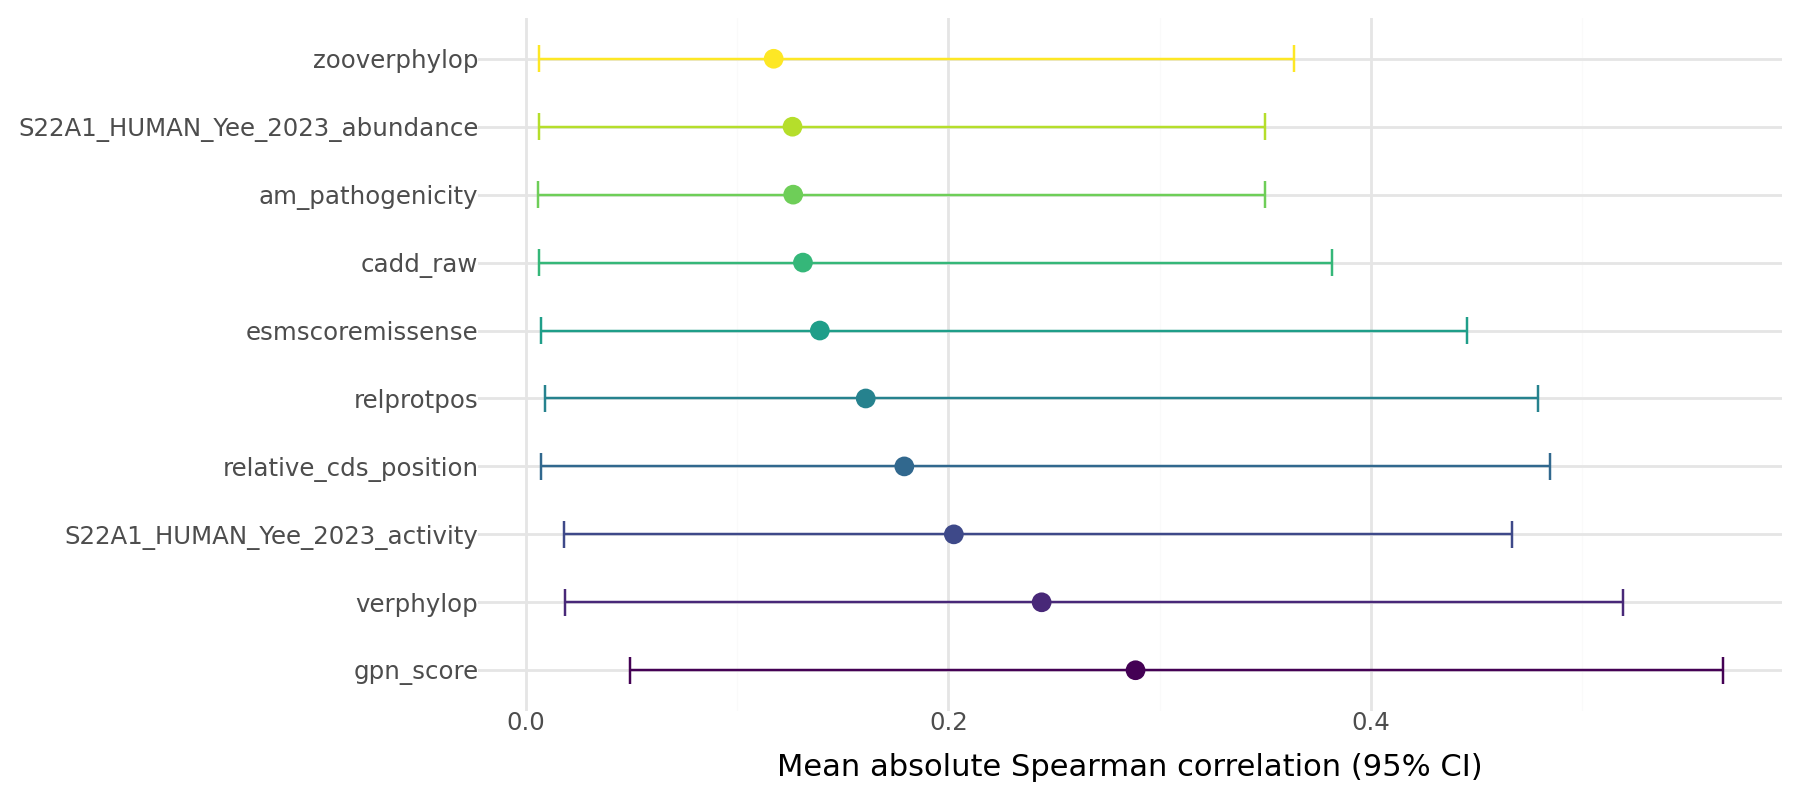

In [7]:
summary_df = final_corr_df.to_pandas()

# Ordering by mean correlation
summary_df['annotation'] = pd.Categorical(
    summary_df['annotation'],
    categories=summary_df.sort_values('mean_abs_corr', ascending=False)['annotation'],
    ordered=True
)

summary_df['color_dms'] = summary_df['annotation'].str.startswith('HXK4').map({True: 'DMS', False: 'Other'})

# Plot
(
    ggplot(summary_df, aes(x='annotation', y='mean_abs_corr', color='annotation')) +
    # geom_col(alpha=0.8) +
    geom_point(size=3) +
    geom_errorbar(aes(ymin='abs_corr_ci_lower', ymax='abs_corr_ci_upper'), width=0.4) +
    coord_flip() +
    theme_minimal() +
    labs(
        x='',
        y='Mean absolute Spearman correlation (95% CI)'
    ) +
    theme(
        figure_size=(9, 4),
        legend_position='none'
    )
)

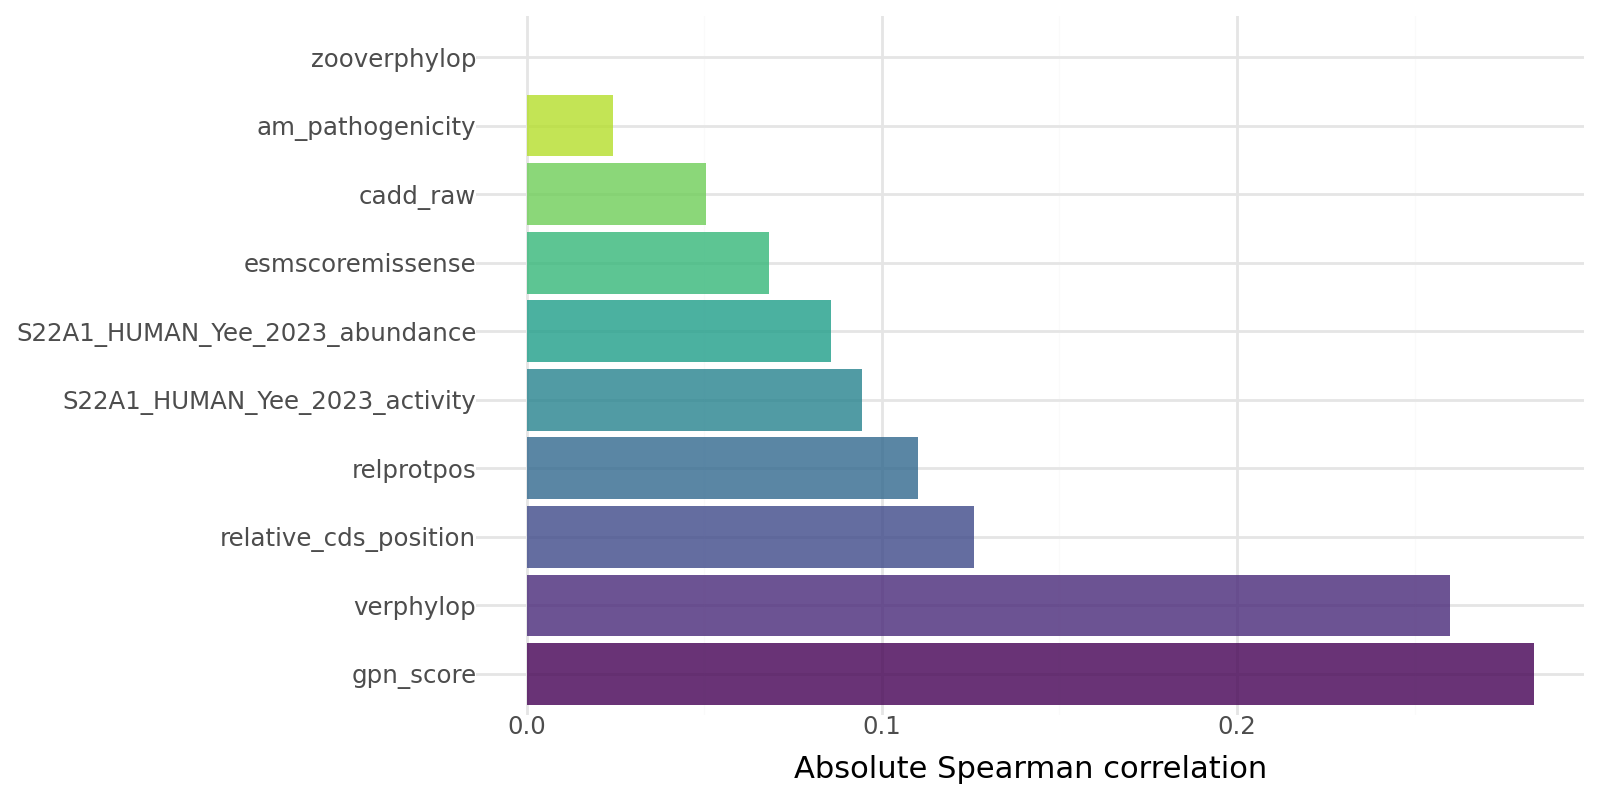

In [8]:
if all_vars:
    med_df = final_corr_df.drop_nans().group_by("annotation").agg([
        pl.col("abs_corr").median().alias("median_abs_corr")
    ])
else:
    med_df = final_corr_df.filter(~pl.col('annotation').str.contains('_allvars')).drop_nans().group_by("annotation").agg([
        pl.col("abs_corr").median().alias("median_abs_corr")
    ])

corr_pd = med_df.join(final_corr_df, on='annotation').to_pandas()

corr_pd['annotation'] = pd.Categorical(
    corr_pd['annotation'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['annotation'].unique(),
    ordered=True
)

# Plot
(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_bar(stat='identity', alpha=0.8) +
    theme_minimal() +
    coord_flip() +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 4),
        legend_position='none'
    )
)

### Debug

In [9]:
pheno_gis_df.filter(
    (pl.col('phenotype') == 'glycated_haemoglobin_hba1c_int') &
    (pl.col('annotation').is_in(['HXK4_HUMAN_Gersing_2022_activity', 'HXK4_HUMAN_Gersing_2023_abundance']))
).sort('id')

id,phenotype,region,annotation,n_individuals,mean_pheno_value,score
str,str,str,str,u32,f64,f32


### Scatter plot

In [10]:
def plot_correlation(plot_df, phenotype, gene_id, annotation, method='spearman'):
    # Filter and add ranks
    df_filtered = plot_df.filter(
        (pl.col('phenotype') == phenotype) &
        (pl.col('region') == gene_id) &
        (pl.col('annotation') == annotation)
    ).with_columns([
        pl.col('score').rank().alias('score_rank'),
        pl.col('mean_pheno_value').rank().alias('pheno_rank')
    ])

    # Determine columns to correlate and plot
    if method.lower() == 'spearman':
        x_col, y_col = 'score_rank', 'pheno_rank'
    elif method.lower() == 'pearson':
        x_col, y_col = 'score', 'mean_pheno_value'
    else:  # Pearson
        sys.exit(f"Unrecognized method. Use 'spearman' or 'pearson'.")

    # Compute correlation using Polars
    corr = df_filtered.select([pl.corr(x_col, y_col, method='pearson')]).to_numpy()[0, 0]

    corr_text = f"{method.title()} r = {corr:.2f}"

    # Build plot
    rc_plot = (
        ggplot(df_filtered.to_pandas(), aes(x=x_col, y=y_col)) +
        geom_point(alpha=0.25) +
        geom_smooth(method='lm', se=True, color='darkred') +
        theme_minimal() +
        labs(
            x=f"{annotation} {'rank' if method.lower()=='spearman' else ''}",
            y=f"{phenotype} residual {'rank' if method.lower()=='spearman' else ''}"
        ) +
        annotate(
            'text',
            x=df_filtered[x_col].min(),
            y=df_filtered[y_col].max(),
            label=corr_text,
            ha='left',
            va='top',
            size=12
        ) +
        theme(figure_size=(5, 4))
    )

    return rc_plot

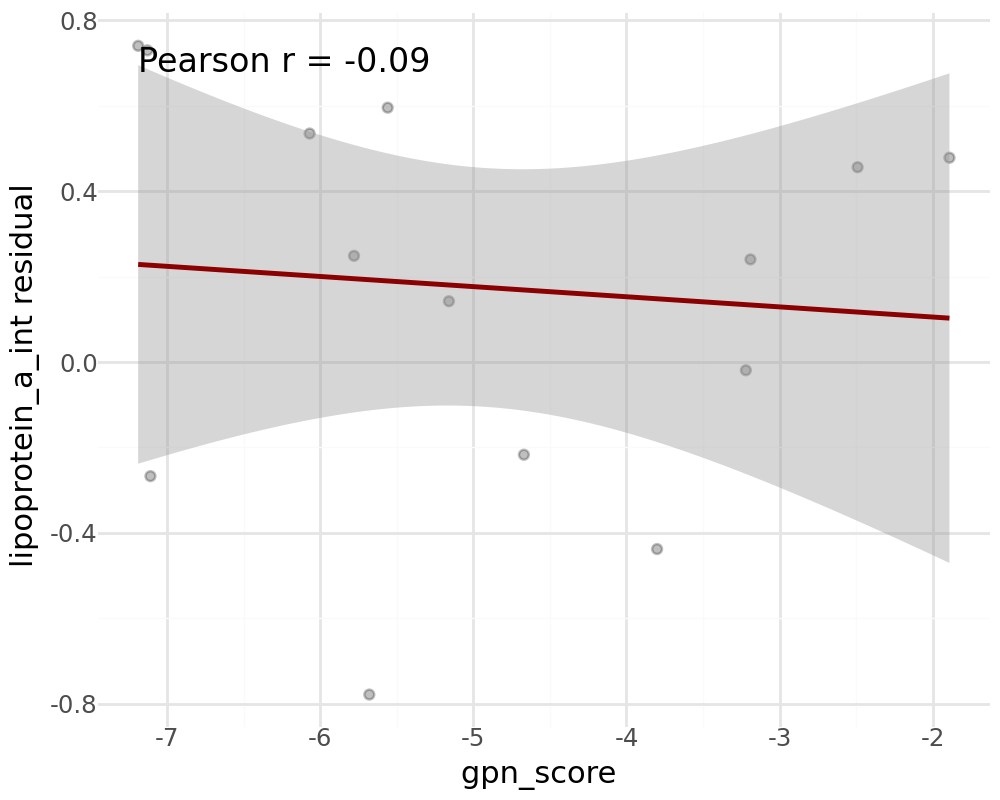

In [11]:
corr_method = 'pearson'
am_plot = plot_correlation(pheno_gis_df, gene_trait_df['phenotype'].item(), gene_trait_df['gene_id'].item(), 'gpn_score', method=corr_method)

am_plot

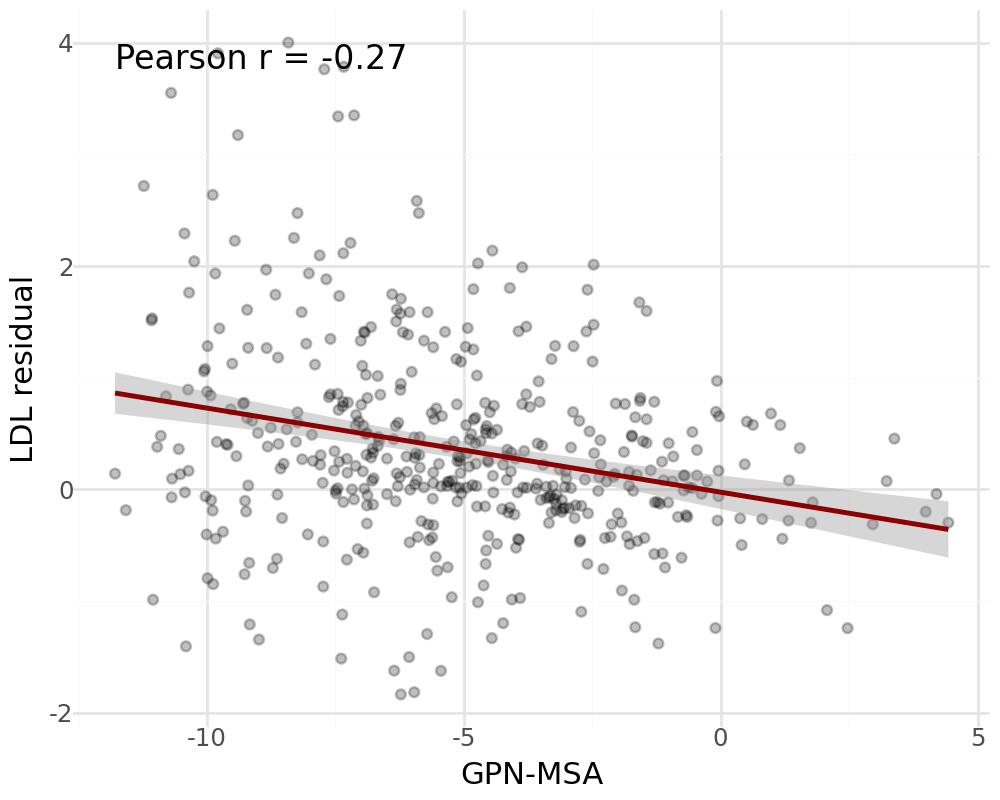

In [217]:
(
    am_plot
    + labs(
        x="GPN-MSA", 
        y=f"LDL residual"
    )
)

### Gene track plot

In [210]:
pheno_gis_df = pheno_gis_df.with_columns(
    pl.col('id').str.split(':').list.get(1).cast(pl.Int64).alias('pos')
)

pheno_df = pheno_gis_df[['pos', 'mean_pheno_value']].unique().sort('pos').to_pandas()
pheno_df

,pos,mean_pheno_value
0,11089556,-0.231471
1,11089574,1.414444
2,11089576,0.365188
3,11089590,-0.454946
4,11089594,0.576216
...,...,...
451,11131289,0.017391
452,11131289,0.283029
453,11131299,0.850899
454,11131308,0.138822


In [211]:
def plot_exon_compressed(
    pheno_df: pd.DataFrame,
    gtf_path: str,
    gene_id: str,
    gap: int = 20,
    exon_thickness: float = 0.1,
):
    """
    Plot phenotype values for variants compressed onto exons of a gene.
    """

    # --- Step 1: Read GTF, get exons for the gene ---
    gtf_cols = [
        "seqname", "source", "feature", "start", "end", "score",
        "strand", "frame", "attribute"
    ]
    gtf = pl.read_csv(
        gtf_path,
        separator="\t",
        has_header=False,
        comment_prefix="##",
        new_columns=gtf_cols
    )
    gtf = gtf.filter(pl.col("feature") == "exon")

    # Extract gene_id from the attribute field
    gtf = gtf.with_columns(
        pl.col("attribute")
        .str.extract(r'gene_id\s*"?([^";]+)"?')
        .str.split(".").list.get(0)
        .alias("gene_id")
    )
    exons = (
        gtf.filter(pl.col("gene_id") == gene_id)
        .select(["start", "end"])
        .to_pandas()
        .sort_values("start")
        .reset_index(drop=True)
    )

    if exons.empty:
        raise ValueError(f"No exons found for gene {gene_id}")

    # --- Step 2: Keep only exons that overlap with variant positions ---
    variant_positions = pheno_df["pos"].values
    exons = exons[
        exons.apply(
            lambda row: ((variant_positions >= row["start"]) & (variant_positions <= row["end"])).any(),
            axis=1,
        )
    ].reset_index(drop=True)

    if exons.empty:
        raise ValueError(f"No exons overlap with variants for gene {gene_id}")

    # --- Step 3: Build compressed coordinate mapping ---
    compressed_map = []
    current_pos = 0

    for _, row in exons.iterrows():
        length = row["end"] - row["start"] + 1
        compressed_map.append({
            "genomic_start": row["start"],
            "genomic_end": row["end"],
            "compressed_start": current_pos,
            "compressed_end": current_pos + length - 1
        })
        current_pos += length + gap

    map_df = pd.DataFrame(compressed_map)

    # --- Step 4: Map variant positions ---
    def map_pos(pos):
        for _, row in map_df.iterrows():
            if row.genomic_start <= pos <= row.genomic_end:
                return row.compressed_start + (pos - row.genomic_start)
        return None

    pheno_df = pheno_df.copy()
    pheno_df["compressed_pos"] = pheno_df["pos"].apply(map_pos)
    pheno_df = pheno_df.dropna(subset=["compressed_pos"])

    # --- Step 5: Build exon rectangles for shading ---
    exon_rects = map_df.assign(
        ymin=-exon_thickness / 2,
        ymax=exon_thickness / 2
    ).rename(columns={"compressed_start": "xmin", "compressed_end": "xmax"})

    return pheno_df, exon_rects

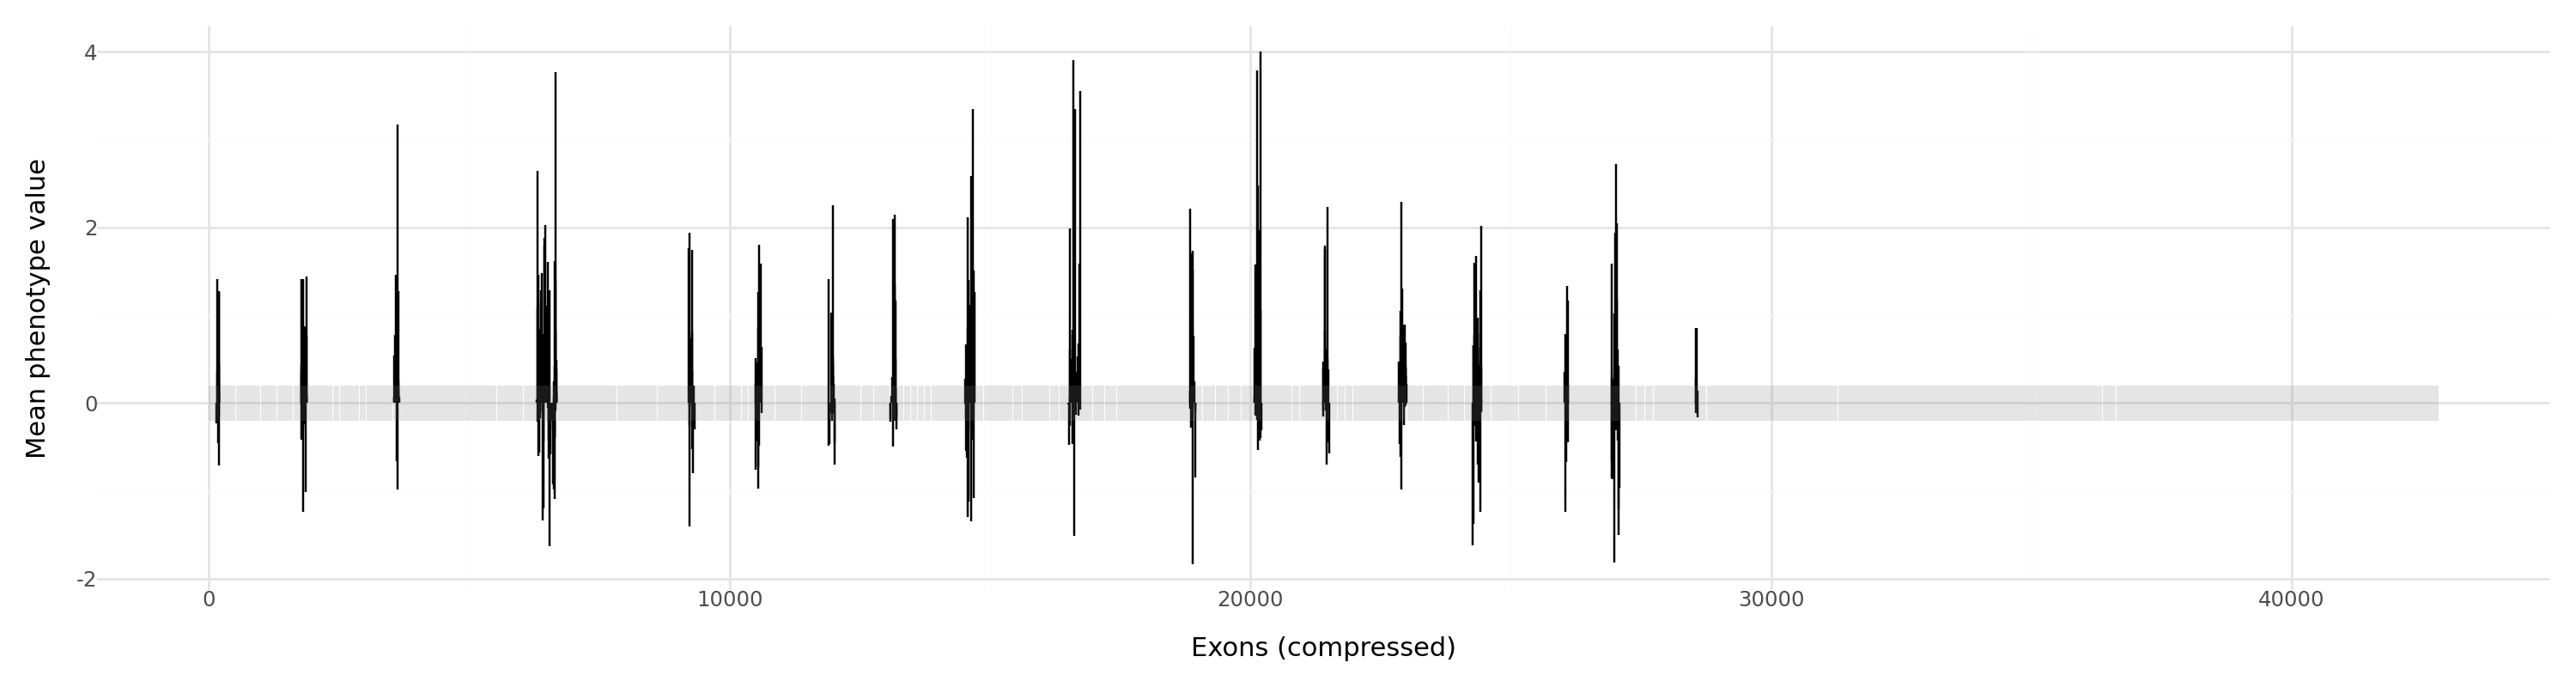

In [212]:
gene_id=gene_trait_df['gene_id'].item()

pheno_df, exon_rects = plot_exon_compressed(
    pheno_df=pheno_df,
    gtf_path='/home/dnanexus/data_dir/gencode.v48.annotation.gtf.gz',
    gene_id=gene_id,
    gap=5,
    exon_thickness=0.4,
)


plot = (
    ggplot(pheno_df, aes(x="compressed_pos", y="mean_pheno_value"))
    # + geom_line()
    + geom_segment(aes(x="compressed_pos", xend="compressed_pos", y=0, yend="mean_pheno_value"))
    + geom_rect(
        data=exon_rects,
        mapping=aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
        inherit_aes=False,
        alpha=0.2,
        fill="gray"
    )
    + theme_minimal()
    + theme(figure_size=(15, 4), legend_position="right")
    + labs(x="Exons (compressed)", y="Mean phenotype value")
)
plot

105

## Debug plotting code

In [153]:
pheno_df=pheno_df
gtf_path='/home/dnanexus/data_dir/gencode.v48.annotation.gtf.gz'
gene_id='ENSG00000106633'
gap=5
exon_thickness=0.4
# --- Step 1: Read GTF, get exons for the gene ---
gtf_cols = [
    "seqname", "source", "feature", "start", "end", "score",
    "strand", "frame", "attribute"
]
gtf = pl.read_csv(
    gtf_path,
    separator="\t",
    has_header=False,
    comment_prefix="##",
    new_columns=gtf_cols
)
gtf = gtf.filter(pl.col("feature") == "exon")

# Extract gene_id from the attribute field
gtf = gtf.with_columns(
    pl.col("attribute")
    .str.extract(r'gene_id\s*"?([^";]+)"?')
    .str.split(".").list.get(0)
    .alias("gene_id")
)
exons = (
    gtf.filter(pl.col("gene_id") == gene_id)
    .select(["start", "end"])
    .to_pandas()
    .sort_values("start")
    .reset_index(drop=True)
)

if exons.empty:
    raise ValueError(f"No exons found for gene {gene_id}")

# --- Step 2: Keep only exons that overlap with variant positions ---
variant_positions = pheno_df["pos"].values
exons = exons[
    exons.apply(
        lambda row: ((variant_positions >= row["start"]) & (variant_positions <= row["end"])).any(),
        axis=1,
    )
].reset_index(drop=True)
exons

,start,end
0,44144273,44145280
1,44144275,44145280
2,44144275,44145280
3,44144275,44145280
4,44144277,44145280
...,...,...
81,44188909,44189439
82,44188909,44189439
83,44188909,44188987
84,44188909,44189439
